In [7]:
import os
import sys
import json
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from itertools import combinations

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask
from etl_pipeline_local import get_btts_table

pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.INFO)
load_dotenv()

True

In [2]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate
# TODO: analisi  univariata KPI più promettenti (Optional)

# 1. Load Data

In [3]:
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"

# Load data
df_loaded = get_btts_table()

df_loaded = df_loaded.sort_values('time').reset_index(drop=True)

# Train/test split
df = df_loaded.copy()
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x["goalNoGoal_quote_currentGG"]), axis=1).copy()

# Adding week column 
df["week"] = df["time"].dt.to_period("W")
monday_start = df["time"].min() - pd.to_timedelta(df["time"].min().weekday(), unit="D")
df["week"] = ((df["time"] - monday_start).dt.days // 7) + 1

df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

## 2. Define Parameters

In [33]:
# Define features and relative step
feature_bins_map = {
    'goalNoGoal_chance_goalHome': 2.5,
    'goalNoGoal_chance_goalAway': 2.5, 
    'goalNoGoal_comparison_affini': 2000,
    'underOver_chance_over15HT': 5,
    'underOver_comparison_affini': 2000,
    'evaluation_valScala': None,
    'evaluation_valMetrica': None,
 }

# feature_bins_map={
#     "evaluation_valScala":None,
#     "evaluation_valMetrica":None,
#     "underOver_chance_over15HT":5,
#     "chance1x2_quote_current1":0.2,
#     "chance1x2_quote_current2":0.2,
#     "goalNoGoal_quote_currentGG":0.2,
#     "goalNoGoal_chance_goal":5,
#     "goalNoGoal_flashback_goal":5,
#     "goalNoGoal_stats_avgGoalHome":0.2,
#     "goalNoGoal_stats_avgGoalTakenAway":0.2,
#     "goalNoGoal_stats_avgGoalTakenHome":0.2,
#     "goalNoGoal_stats_avgGoalAway":0.2
# }

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 10, # 50
    "min_obs": 100, 
    "lambda": 0.5, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

In [34]:
# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: goalNoGoal_chance_goalHome
Search space: [  0.   15.   17.5  20.   22.5  25.   27.5  30.   32.5  35.   37.5  40.
  42.5  45.   47.5  50.   52.5  55.   57.5  60.   62.5  65.   67.5  70.
  72.5  75.   77.5  80.   82.5  85.   87.5  90.   92.5  95.   97.5 100. ]


Feature: goalNoGoal_chance_goalAway
Search space: [  0.   12.5  15.   20.   22.5  25.   27.5  30.   32.5  35.   37.5  40.
  42.5  45.   47.5  50.   52.5  55.   57.5  60.   62.5  65.   67.5  70.
  72.5  75.   77.5  80.   82.5  85.   87.5  90.   92.5  95.   97.5 100. ]


Feature: goalNoGoal_comparison_affini
Search space: <IntegerArray>
[0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000, 22000]
Length: 12, dtype: Int64


Feature: underOver_chance_over15HT
Search space: <IntegerArray>
[15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
Length: 12, dtype: Int64


Feature: underOver_comparison_affini
Search space: <IntegerArray>
[0, 2000, 4000, 6000, 8000, 10000, 12000, 16000, 18000]
Length: 9, dt

## 3. Optimize

In [35]:
def objective(trial, min_obs, _lambda):
    mask = pd.Series(True, index=df_train_binned.index)
    params_dict_item = dict()

    for feat, step in feature_bins_map.items():

        s = df_train_binned[feat]
        non_null = s.dropna()

        if non_null.empty:
            continue

        # ---------------------------------
        # CASO 1: variabile categorica
        # ---------------------------------
        if not step:
            # ordine stabile e deterministico
            unique_vals = sorted(map(str, non_null.unique()))

            categorical_set = [
                list(c)
                for r in range(1, len(unique_vals) + 1)
                for c in combinations(unique_vals, r)
            ]

            idx = trial.suggest_categorical(
                f"{feat}_cat_idx",
                list(range(len(categorical_set)))
            )

            categorical_feat = categorical_set[idx]
            # trial.set_user_attr(f"{feat}_cat", categorical_feat)
            params_dict_item[f"{feat}_cat"] = categorical_feat


        # ---------------------------------
        # CASO 2: numerica continua/intera
        # ---------------------------------
        else:
            # TODO: se la feature ha valori nulli, introduco include_missing feature, valutare rimozione  
            if s.isna().sum() > 0:
                include_missing = trial.suggest_categorical(
                    f"{feat}_include_missing",
                    [True, False]
                )
                # trial.set_user_attr(f"{feat}_include_missing", include_missing)
                params_dict_item[f"{feat}_include_missing"] = include_missing

            # TODO: vincolo per >=, <=, <,>, da studiare
            use_min = trial.suggest_categorical(f"{feat}_use_min", [True, False])
            use_max = trial.suggest_categorical(f"{feat}_use_max", [True, False])

            # trial.set_user_attr(f"{feat}_use_min", use_min)
            # trial.set_user_attr(f"{feat}_use_max", use_max)
            params_dict_item[f"{feat}_use_min"] = use_min
            params_dict_item[f"{feat}_use_max"] = use_max
            

            # TODO: questo dovrebbe forzare l'utilizzo della feature, da capire se forzarlo è utile o meno
            # # almeno un vincolo deve essere attivo
            if not use_min and not use_max:
                raise optuna.TrialPruned()
            
            if pd.api.types.is_integer_dtype(s):
                feat_min = trial.suggest_int(
                    name=f"{feat}_min",
                    low=int(non_null.min()),
                    high=int(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_int(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=int(non_null.max()), 
                    step=step
                )
                # trial.set_user_attr(f"{feat}_min", feat_min)
                # trial.set_user_attr(f"{feat}_max", feat_max)
                params_dict_item[f"{feat}_min"] = feat_min
                params_dict_item[f"{feat}_max"] = feat_max
            else:
                feat_min = trial.suggest_float(
                    name=f"{feat}_min",
                    low=float(non_null.min()),
                    high=float(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_float(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=float(non_null.max()),
                    step=step
                )
                # trial.set_user_attr(f"{feat}_min", feat_min)
                # trial.set_user_attr(f"{feat}_max", feat_max)
                params_dict_item[f"{feat}_min"] = feat_min
                params_dict_item[f"{feat}_max"] = feat_max

        trial.set_user_attr("params_dict", params_dict_item)

        # costruzione maschera feature
        feat_mask = pd.Series(True, index=s.index)

        if not step:
            # Categorical filtering
            feat_mask &= s.isin(categorical_feat)
        else:
            # Numerical filtering
            if use_min:
                feat_mask &= s >= feat_min

            if use_max:
                feat_mask &= s <= feat_max

            # Filtering for feature with nan
            if s.isna().sum() > 0:
                if include_missing:
                    feat_mask = feat_mask | s.isna()
                else:
                    feat_mask = feat_mask & s.notna()

        mask &= feat_mask

    selected = df_train_binned.loc[mask]

    if len(selected) <= 0:
        return -1e9
    
    mean_weekly_return = selected.groupby("week")["return"].sum().mean() # massimizzo ritorno settimanale
    std_weekly_return = selected.groupby("week")["return"].sum().std(ddof=0) # minimizzo volatilità ritorno settimanale


    if len(selected) < min_obs:
        return -1e9
    
    score = mean_weekly_return - _lambda * std_weekly_return 

    return float(score)

In [36]:
def run_one_study(seed, n_trials):
    sampler = optuna.samplers.TPESampler(
        seed=seed,
        multivariate=False,
        group=False,
        n_startup_trials=objective_hyperparameters["tpe_sampler"]["n_startup_trials"], 
        n_ei_candidates=objective_hyperparameters["tpe_sampler"]["n_ei_candidates"], 
    )
    study = optuna.create_study(direction="maximize", sampler=sampler,) # gc is garbage collector, when set to True it prevents running otu of memory

    study.optimize(
        lambda trial: objective(trial=trial, min_obs=objective_hyperparameters["min_obs"], _lambda=objective_hyperparameters["lambda"]), 
        n_trials=n_trials
        )
    return study


studies = [run_one_study(seed=s, n_trials=objective_hyperparameters["n_trials"]) for s in range(objective_hyperparameters["n_studies"])]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials =[x for x in top_trials if x.value > 0]

[I 2026-04-01 13:07:10,271] A new study created in memory with name: no-name-060071d1-d231-4161-83e2-99e6a4d2733a
[I 2026-04-01 13:07:10,278] Trial 0 pruned. 
[I 2026-04-01 13:07:10,280] Trial 1 pruned. 
[I 2026-04-01 13:07:10,283] Trial 2 pruned. 
[I 2026-04-01 13:07:10,287] Trial 3 pruned. 
[I 2026-04-01 13:07:10,289] Trial 4 pruned. 
[I 2026-04-01 13:07:10,290] Trial 5 pruned. 
[I 2026-04-01 13:07:10,290] Trial 6 pruned. 
[I 2026-04-01 13:07:10,291] Trial 7 pruned. 
[I 2026-04-01 13:07:10,294] Trial 8 pruned. 
[I 2026-04-01 13:07:10,296] Trial 9 pruned. 
[I 2026-04-01 13:07:10,297] Trial 10 pruned. 
[I 2026-04-01 13:07:10,299] Trial 11 pruned. 
[I 2026-04-01 13:07:10,300] Trial 12 pruned. 
[I 2026-04-01 13:07:10,311] Trial 13 finished with value: -1.5145215620051198 and parameters: {'goalNoGoal_chance_goalHome_use_min': True, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 30.0, 'goalNoGoal_chance_goalHome_max': 77.5, 'goalNoGoal_chance_goalAway_use_min

## 4. Evaluate

In [37]:
# Create the test binned dataframe
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = top_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_score = df.groupby('week')['return'].sum().min()
    max_score = df.groupby('week')['return'].sum().max()
    print(f"Trial no. {i}")
    print(f"Min score {min_score}")
    print(f"Max score {max_score}")
    print("\n")

Trial no. 0
Min score -3.0500000000000003
Max score 6.55


Trial no. 1
Min score -2.0500000000000003
Max score 5.45


Trial no. 2
Min score -2.0
Max score 4.2


Trial no. 3
Min score -2.0
Max score 5.45


Trial no. 4
Min score -2.0
Max score 5.45


Trial no. 5
Min score -1.47
Max score 3.26


Trial no. 6
Min score -2.0
Max score 5.45


Trial no. 7
Min score -2.0
Max score 5.45


Trial no. 8
Min score -2.0
Max score 5.45


Trial no. 9
Min score -2.2299999999999995
Max score 5.32


Trial no. 10
Min score -1.9
Max score 3.3200000000000003


Trial no. 11
Min score -2.45
Max score 3.79


Trial no. 12
Min score -2.45
Max score 3.79


Trial no. 13
Min score -2.45
Max score 3.79


Trial no. 14
Min score -2.45
Max score 3.79


Trial no. 15
Min score -2.45
Max score 3.79


Trial no. 16
Min score -3.06
Max score 3.79




In [38]:
best_score_idx = 0

params_dict = top_trials[best_score_idx].user_attrs

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]

# df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
# min_score = df.groupby('week')['return'].sum().min()
# max_score = df.groupby('week')['return'].sum().max()

mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")

Mean Train ROI: -0.023635145696103598
Train Accuracy: 0.5 (4895/8957)


In [39]:
mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")

Mean Test ROI: -0.03789732142857142
Test Accuracy: 0.5 (1167/2240)


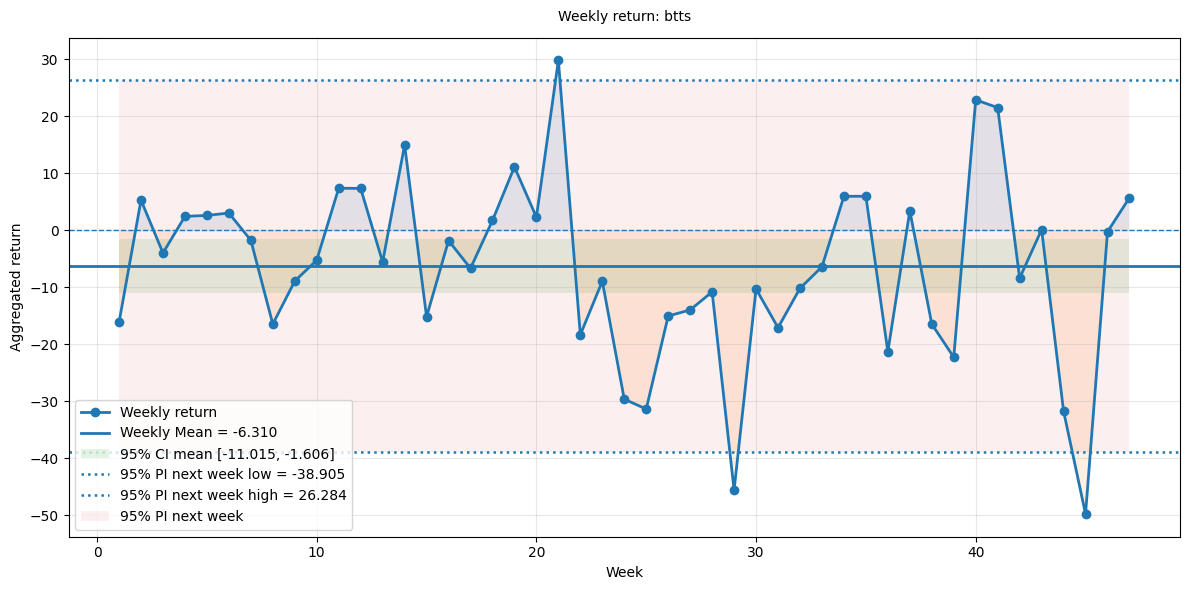

In [40]:
sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [24]:
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")

No. of weeks covered: 47/46 (1.02)


In [25]:
get_best_strategies(df_tot_filtered)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,-6.31,16.02,238.23,150.04,11197,0.55


## 5. Save best Trials

In [ ]:
# Save best trials 
trials_to_save = best_trials[:1]

for trial in trials_to_save:
    trial.set_user_attr("feature_bins_map", feature_bins_map)

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

def trial_key(t: optuna.trial.FrozenTrial) -> str:
    # chiave semplice per evitare di aggiungere due volte lo stesso best trial
    return json.dumps(
        {
            "params": t.params,
            "value": t.value,
        },
        sort_keys=True,
        default=str,
    )

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in trials_to_save
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)
